In [6]:
import pandas as pd

GDP_df = pd.read_csv(
    "https://data.un.org/_Docs/SYB/CSV/SYB68_230_202511_GDP%20and%20GDP%20Per%20Capita.csv",
    encoding="latin1",
     skiprows=2, header=None)
GDP_df.columns = ["country_code", "country_name", "year", "series", "value", "footnotes", "source"]

Energy_df = pd.read_csv(
    "https://data.un.org/_Docs/SYB/CSV/SYB68_263_202511_Production,%20Trade%20and%20Supply%20of%20Energy.csv",
    encoding="latin1",
    skiprows=2, header=None)
Energy_df.columns = ["country_code", "country_name", "year", "series", "value", "footnotes", "source"]


In [7]:
# Data Acquisition with SHA-256 Integrity Check
import hashlib
import urllib.request
import os

DATASETS = {
    "GDP and GDP Per Capita.csv": (
        "https://data.un.org/_Docs/SYB/CSV/"
        "SYB68_230_202511_GDP%20and%20GDP%20Per%20Capita.csv"
    ),
    "Energy Production and Supply.csv": (
        "https://data.un.org/_Docs/SYB/CSV/"
        "SYB68_263_202511_Production,%20Trade%20and%20Supply%20of%20Energy.csv"
    ),
}

os.makedirs("datasets", exist_ok=True)

checksums = {}
for filename, url in DATASETS.items():
    local_path = os.path.join("datasets", filename)

    # Download if not already present
    if not os.path.exists(local_path):
        print(f"Downloading {filename}...")
        urllib.request.urlretrieve(url, local_path)
    else:
        print(f"Using cached {filename}")

    # Compute SHA-256
    with open(local_path, "rb") as f:
        digest = hashlib.sha256(f.read()).hexdigest()
    checksums[filename] = digest
    print(f"  SHA-256: {digest}")

# Persist the checksums to disk for the repo
with open("checksums.txt", "w") as f:
    for filename, digest in checksums.items():
        f.write(f"{digest}  {filename}\n")

print("Integrity check complete. Hashes saved to checksums.txt")

Using cached GDP and GDP Per Capita.csv
  SHA-256: 8091d7ba3b94ad60477a66cd41fd7b0a1dd1cafd5014ccda74f6c6032e9da9ac
Using cached Energy Production and Supply.csv
  SHA-256: 425460565f23d953116e9233a3548d6e51ee2d4b14bc3348e6886aee3119ece2
Integrity check complete. Hashes saved to checksums.txt


In [8]:
# Diagnostic — paste after your existing first cell
print("=== ENERGY dataset ===")
print(f"All years: {sorted(Energy_df['year'].unique())}")
print(f"Range: {Energy_df['year'].min()} – {Energy_df['year'].max()}")

print("\n=== GDP dataset ===")
print(f"All years: {sorted(GDP_df['year'].unique())}")
print(f"Range: {GDP_df['year'].min()} – {GDP_df['year'].max()}")

# Continental aggregates only
CONTINENT_CODES = [2, 9, 21, 142, 150, 419]

energy_cont_years = sorted(Energy_df[Energy_df["country_code"].isin(CONTINENT_CODES)]["year"].unique())
gdp_cont_years    = sorted(GDP_df[GDP_df["country_code"].isin(CONTINENT_CODES)]["year"].unique())

print(f"\nEnergy continental years: {energy_cont_years}")
print(f"GDP    continental years: {gdp_cont_years}")

=== ENERGY dataset ===
All years: [np.int64(1995), np.int64(2000), np.int64(2005), np.int64(2010), np.int64(2015), np.int64(2020), np.int64(2021), np.int64(2022)]
Range: 1995 – 2022

=== GDP dataset ===
All years: [np.int64(1995), np.int64(2005), np.int64(2010), np.int64(2015), np.int64(2020), np.int64(2022), np.int64(2023)]
Range: 1995 – 2023

Energy continental years: [np.int64(1995), np.int64(2000), np.int64(2005), np.int64(2010), np.int64(2015), np.int64(2020), np.int64(2021), np.int64(2022)]
GDP    continental years: [np.int64(1995), np.int64(2005), np.int64(2010), np.int64(2015), np.int64(2020), np.int64(2022), np.int64(2023)]


In [9]:
CONTINENT_CODES = {"Africa": 2,"Asia": 142,"Europe": 150,"Oceania": 9,"North America": 21,"Latin America & Caribbean": 419,}

CODE_TO_NAME = {v: k for k, v in CONTINENT_CODES.items()}

def clean_and_map(df):
    df = df.copy()

    df["value"] = (
        df["value"]
        .astype(str)
        .str.replace(",", "", regex=False)
        .pipe(pd.to_numeric, errors="coerce")
    )

    df = df[df["country_code"].isin(CODE_TO_NAME)].copy()
    df["continent"] = df["country_code"].map(CODE_TO_NAME)

    return df

gdp_cont = clean_and_map(GDP_df)
energy_cont = clean_and_map(Energy_df)

In [10]:
def make_pivot(df):
    return (
        df.pivot_table(
            index=["continent", "year"],
            columns="series",
            values="value"
        )
        .reset_index()
        .rename_axis(None, axis=1)
    )

gdp_pivot = make_pivot(gdp_cont)
energy_pivot = make_pivot(energy_cont)

In [11]:
merged = pd.merge(gdp_pivot, energy_pivot, on=["continent", "year"], how="inner")
merged = merged[merged["year"] != 2023]   # GDP has 2023; energy does not

merged.rename(columns={
    "GDP in current prices (millions of US dollars)":        "gdp_current_musd",
    "GDP in constant 2015 prices (millions of US dollars)":  "gdp_constant_musd",
    "GDP per capita (US dollars)":                           "gdp_per_capita_usd",
    "GDP real rates of growth (percent)":                    "gdp_growth_pct",
    "Primary energy production (petajoules)":                "energy_production_pj",
    "Total supply (petajoules)":                             "energy_supply_pj",
    "Supply per capita (gigajoules)":                        "energy_per_capita_gj",
    "Net imports [Imports - Exports - Bunkers] (petajoules)":"net_imports_pj",
    "Changes in stocks (petajoules)":                        "stock_changes_pj",
}, inplace=True)

In [12]:

merged["energy_intensity"] = (
    merged["energy_supply_pj"] / merged["gdp_current_musd"] * 1_000
)

In [13]:
merged

,continent,year,gdp_constant_musd,gdp_current_musd,gdp_per_capita_usd,gdp_growth_pct,stock_changes_pj,net_imports_pj,energy_production_pj,energy_per_capita_gj,energy_supply_pj,energy_intensity
0,Africa,1995,987958.0,604663.0,826.0,2.8,321.0,-13032.0,30190.0,23.0,16838.0,27.846916
1,Africa,2005,1537908.0,1171121.0,1244.0,6.2,7.0,-20496.0,42513.0,23.0,22010.0,18.793959
2,Africa,2010,2007594.0,2045219.0,1910.0,6.2,75.0,-19183.0,44563.0,24.0,25304.0,12.372269
3,Africa,2015,2417147.0,2417147.0,1984.0,3.4,-16.0,-13333.0,41485.0,23.0,28169.0,11.653822
4,Africa,2020,2640654.0,2481548.0,1799.0,-2.7,64.0,-10335.0,40413.0,22.0,30015.0,12.095273
5,Africa,2022,2869391.0,2909448.0,2013.0,3.7,68.0,-9748.0,41689.0,22.0,31873.0,10.954999
6,Asia,1995,10021148.0,9344094.0,2680.0,5.6,568.0,-8705.0,133503.0,36.0,124229.0,13.294922
7,Asia,2005,15763522.0,12552040.0,3144.0,6.4,-359.0,-9239.0,191215.0,46.0,182336.0,14.526404
8,Asia,2010,20955094.0,21206220.0,5003.0,7.8,1649.0,177.0,235352.0,55.0,233880.0,11.028840
9,Asia,2015,27046261.0,27046261.0,6034.0,4.9,-6.0,8014.0,259995.0,60.0,268015.0,9.909503


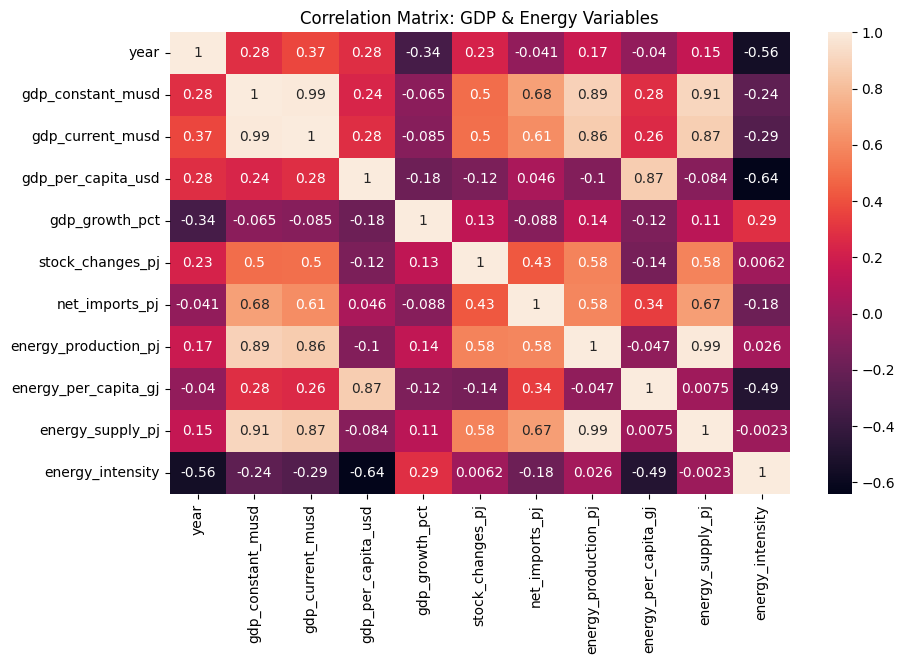

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = merged.select_dtypes(include="number").corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix: GDP & Energy Variables")
plt.show()

In [15]:
import statsmodels.api as sm
features = [
    "energy_per_capita_gj",
    "energy_supply_pj",
    "energy_production_pj"
]

df = merged.dropna(subset=features + ["gdp_per_capita_usd"])

X = sm.add_constant(df[features])
y = df["gdp_per_capita_usd"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     gdp_per_capita_usd   R-squared:                       0.852
Model:                            OLS   Adj. R-squared:                  0.839
Method:                 Least Squares   F-statistic:                     61.58
Date:                Tue, 05 May 2026   Prob (F-statistic):           2.19e-13
Time:                        07:58:40   Log-Likelihood:                -372.20
No. Observations:                  36   AIC:                             752.4
Df Residuals:                      32   BIC:                             758.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                 -1.12e+04 

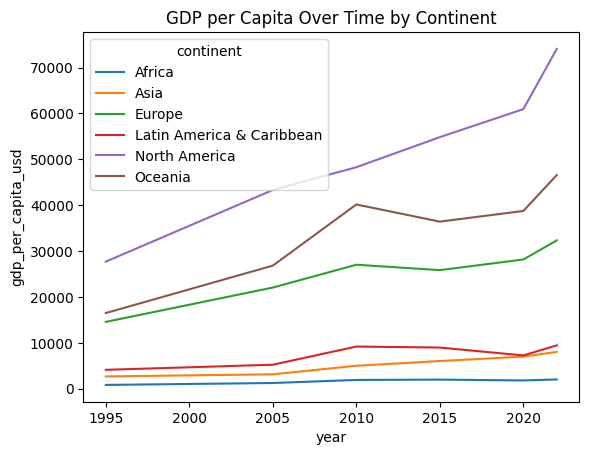

In [16]:
sns.lineplot(
    data=merged,
    x="year",
    y="gdp_per_capita_usd",
    hue="continent"
)
plt.title("GDP per Capita Over Time by Continent")
plt.show()

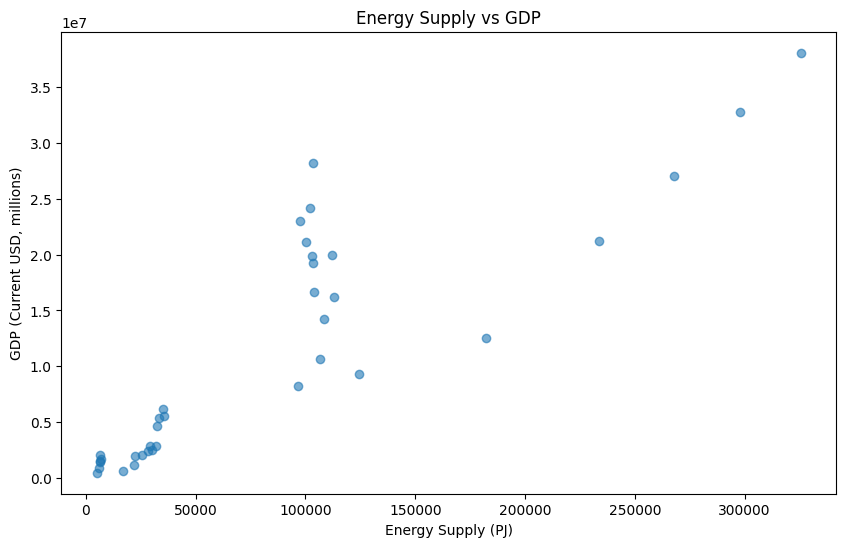

In [17]:
plt.figure(figsize=(10,6))
plt.scatter(
    merged["energy_supply_pj"],
    merged["gdp_current_musd"],
    alpha=0.6
)
plt.xlabel("Energy Supply (PJ)")
plt.ylabel("GDP (Current USD, millions)")
plt.title("Energy Supply vs GDP")
plt.show()

In [18]:
# Record of specific packages used
!pip freeze | grep -iE "^(pandas|numpy|matplotlib|seaborn|statsmodels|scipy|patsy|six|python-dateutil|pytz|pillow|kiwisolver|fonttools|cycler|pyparsing|contourpy|packaging)=" > pip_freeze.tx